# 04 — Analysis
## Classification Evaluation + Recommendations + Visualization

Evaluation of classification results (rule engine + ML fallback),
recommendations for fixing anti-patterns, and final visualizations.

Modules used: `evaluator.py`, `recommender.py`

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

from recommender import Recommender

with open(Path.cwd().parent / "output" / "intermediate_03.pkl", "rb") as f:
    data = pickle.load(f)

rule_results = data["rule_results"]
final_predictions = np.array(data["final_predictions"])
ml_predictions = data["ml_predictions"]
phi = data["phi"]
schema = data["schema"]
column_index = data["column_index"]
gt_labels = data["gt_labels"]

print(f"Loaded: {len(column_index)} columns")
print(f"Rule engine results: {len(rule_results)}")
print(f"Unique predictions: {len(set(final_predictions))}")

Loaded: 243 columns
Rule engine results: 243
Unique predictions: 10


## 1. Classification Metrics

In [2]:
# Full metrics (all columns)
f1_macro = f1_score(gt_labels, final_predictions, average="macro", zero_division=0.0)
f1_weighted = f1_score(gt_labels, final_predictions, average="weighted", zero_division=0.0)
accuracy = accuracy_score(gt_labels, final_predictions)

print("=== Full Metrics (all columns) ===")
print(f"  Accuracy:          {accuracy:.4f}")
print(f"  F1-macro:          {f1_macro:.4f}")
print(f"  F1-weighted:       {f1_weighted:.4f}")

# Active metrics (only non-clean detections)
active_mask = final_predictions != "clean"
active_pred = final_predictions[active_mask]
active_true = gt_labels[active_mask]

if len(active_pred) > 0:
    f1_macro_active = f1_score(active_true, active_pred, average="macro", zero_division=0.0)
    f1_weighted_active = f1_score(active_true, active_pred, average="weighted", zero_division=0.0)
    accuracy_active = accuracy_score(active_true, active_pred)
    print(f"\n=== Detection Precision (only {len(active_pred)} non-clean columns) ===")
    print(f"  Accuracy:          {accuracy_active:.4f}")
    print(f"  F1-macro:          {f1_macro_active:.4f}")
    print(f"  F1-weighted:       {f1_weighted_active:.4f}")
else:
    print("\nNo anti-patterns detected.")

print(f"\n  Unique classes:    {len(set(gt_labels))}")

=== Full Metrics (all columns) ===
  Accuracy:          0.9877
  F1-macro:          0.9057
  F1-weighted:       0.9816

=== Detection Precision (only 176 non-clean columns) ===
  Accuracy:          0.9943
  F1-macro:          0.8978
  F1-weighted:       0.9915

  Unique classes:    11


In [3]:
print("Classification Report (per class, all columns):")
print(classification_report(gt_labels, final_predictions, zero_division=0.0))

Classification Report (per class, all columns):
                     precision    recall  f1-score   support

        bad_boolean       1.00      1.00      1.00         4
              clean       0.97      1.00      0.98        65
                eav       1.00      1.00      1.00         6
        giant_table       1.00      1.00      1.00       106
    impossible_data       0.00      0.00      0.00         3
inconsistent_naming       1.00      1.00      1.00        27
     number_as_text       1.00      1.00      1.00         3
        polymorphic       1.00      1.00      1.00         2
     reserved_words       1.00      1.00      1.00         4
   self_referencing       1.00      1.00      1.00         1
   wrong_data_types       0.96      1.00      0.98        22

           accuracy                           0.99       243
          macro avg       0.90      0.91      0.91       243
       weighted avg       0.98      0.99      0.98       243



In [4]:
n_matched = sum(1 for r in rule_results if r.predicted_label != "clean")
n_clean = sum(1 for p in final_predictions if p == "clean")

print("Rule Engine Coverage:")
print(f"  Total columns:     {len(column_index)}")
print(f"  Rule-matched:      {n_matched}")
print(f"  Clean:             {n_clean}")
print(f"  Coverage:          {n_matched / len(column_index):.1%}")

Rule Engine Coverage:
  Total columns:     243
  Rule-matched:      176
  Clean:             67
  Coverage:          72.4%


In [5]:
uncovered_indices = [i for i, r in enumerate(rule_results) if r.predicted_label == "clean"]
if uncovered_indices:
    print(f"Columns not detected by rules: {len(uncovered_indices)} (treated as clean)")
    for idx in uncovered_indices[:10]:
        print(f"  {column_index[idx]}")
    if len(uncovered_indices) > 10:
        print(f"  ... and {len(uncovered_indices) - 10} more")
else:
    print("All columns covered by rules.")

Columns not detected by rules: 67 (treated as clean)
  AUDITORIA_LOG.ID
  AUDITORIA_LOG.TABLA_AFECTADA
  AUDITORIA_LOG.REGISTRO_ID
  AUDITORIA_LOG.ACCION
  AUDITORIA_LOG.USUARIO
  AUDITORIA_LOG.DETALLE
  CACHE_TEMPORAL.ID
  CACHE_TEMPORAL.DATOS
  CACHE_TEMPORAL.RESULTADO
  CATEGORIAS.ID
  ... and 57 more


## 2. Recommendations

In [6]:
recommender = Recommender()
recommendations = recommender.recommend(schema)
print(recommender.print_recommendations(recommendations))

COLUMN-LEVEL ISSUES

🔴 [WRONG_DATA_TYPES] Found in 30 columns:
   Columns: FECHA, FECHA, FECHA_ACTUALIZACION, FECHA_ALTA, FECHA_CAMBIO, FECHA_EXPIRACION, FECHA_GENERACION, FECHA_NACIMIENTO, FECHA_ORDEN, FECHA_O_DIRECCION... (+20 more)
   ✅ Action: Review and fix;

🟡 [SELF_CONTRADICTORY] Found in 10 columns:
   Columns: ACTIVO, ACTIVO, ACTIVO, ACTIVO, ESTADO_O_ACTIVO, FLAG_1_0, FLAG_ACTIVO, FLAG_S_N, FLAG_T_F, FLAG_Y_N
   ✅ Action: Review and fix;

🔴 [RESERVED_WORDS] Found in 5 columns:
   Columns: FROM, NULL, SELECT, TIMESTAMP, WHERE
   ✅ Action: Review and fix;

🟡 [POLYMORPHIC] Found in 4 columns:
   Columns: TIPO, TIPO_DATO, TIPO_DATO, TIPO_REGISTRO
   ✅ Action: Use separate tables per type or FK constraint per type;

🟡 [IMPLICIT_FK] Found in 2 columns:
   Columns: EMPLEADO_ID, PROVEEDORES_ID
   ✅ Action: Add a FOREIGN KEY constraint to the referenced table;

🟢 [OVERSIZED_VARCHAR] Found in 2 columns:
   Columns: FLAG_ACTIVO, ESTADO_O_ACTIVO
   ✅ Action: Reduce VARCHAR2 size to match 

## 3. Feature Importance

In [7]:
clf = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)
scores = cross_val_score(clf, phi, gt_labels, cv=5, scoring="f1_macro")
print(f"Random Forest F1-macro (CV): {scores.mean():.4f} +/- {scores.std():.4f}")

clf.fit(phi, gt_labels)
importances = clf.feature_importances_
top_indices = np.argsort(importances)[-10:][::-1]
print("\nTop 10 features:")
for idx in top_indices:
    print(f"  Feature {idx}: {importances[idx]:.4f}")

/Users/jesusmarentes/Documents/DocumentsJesus/db_bad_clust/.venv/lib/python3.14/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Random Forest F1-macro (CV): 0.2255 +/- 0.0532

Top 10 features:
  Feature 292: 0.0145
  Feature 139: 0.0131
  Feature 245: 0.0125
  Feature 12: 0.0104
  Feature 344: 0.0097
  Feature 86: 0.0088
  Feature 33: 0.0086
  Feature 299: 0.0084
  Feature 360: 0.0080
  Feature 217: 0.0079


In [8]:
# Clustering vs manual ground truth (ARI)
from validation import GroundTruthValidator
from sklearn.decomposition import PCA
import hdbscan

pca = PCA(n_components=min(20, phi.shape[1]), random_state=42)
Xp = pca.fit_transform(phi)
cluster_labels = hdbscan.HDBSCAN(min_cluster_size=5, min_samples=2, metric="euclidean").fit_predict(Xp)

validator = GroundTruthValidator()
ari = validator.adjusted_rand_index(cluster_labels, gt_labels)
nmi = validator.normalized_mutual_info(cluster_labels, gt_labels)
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
print(f"HDBSCAN: {n_clusters} clusters | ARI: {ari:.4f} | NMI: {nmi:.4f}")

HDBSCAN: 9 clusters | ARI: 0.2491 | NMI: 0.3921


## 4. Visualizations

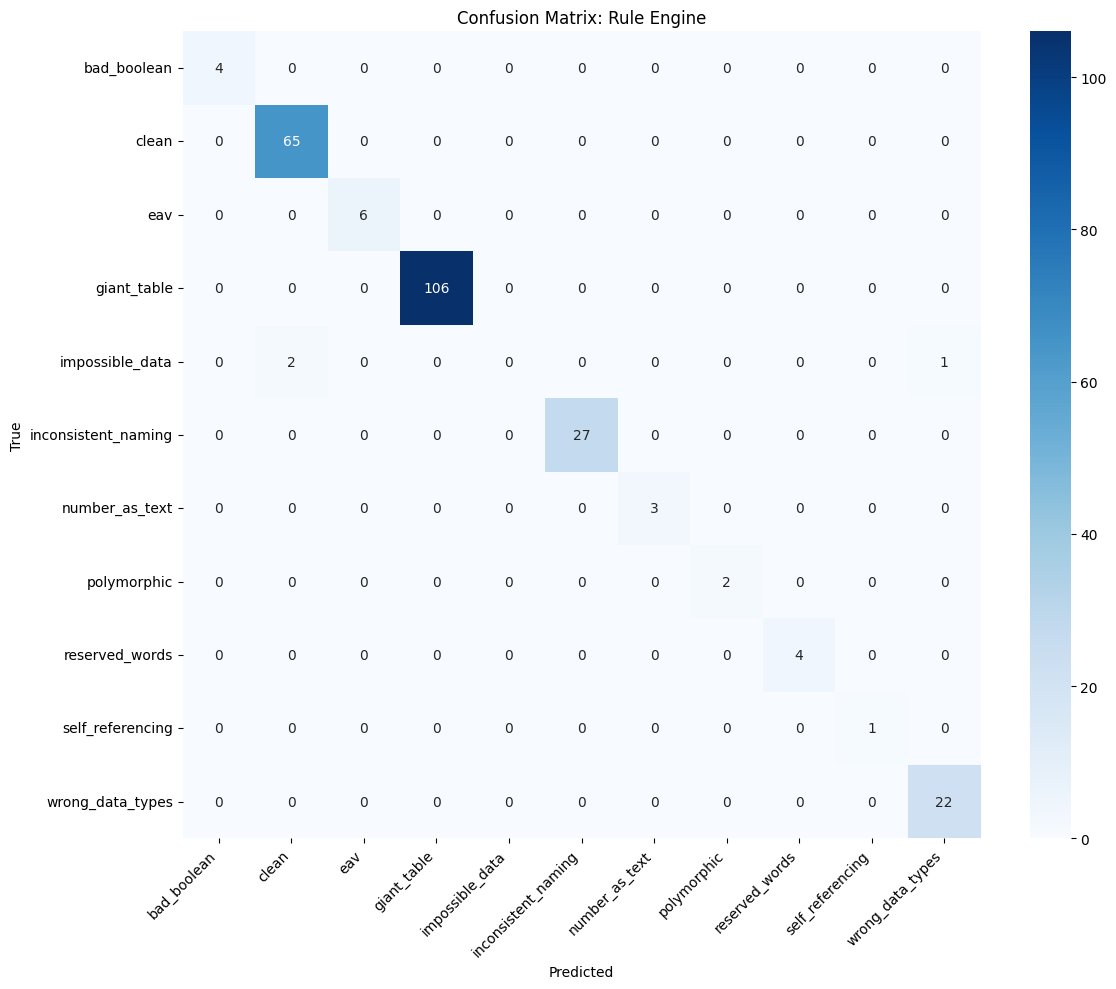

In [9]:
cm = confusion_matrix(gt_labels, final_predictions, labels=sorted(set(gt_labels)))
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sorted(set(gt_labels)),
    yticklabels=sorted(set(gt_labels)),
)
plt.title("Confusion Matrix: Rule Engine")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

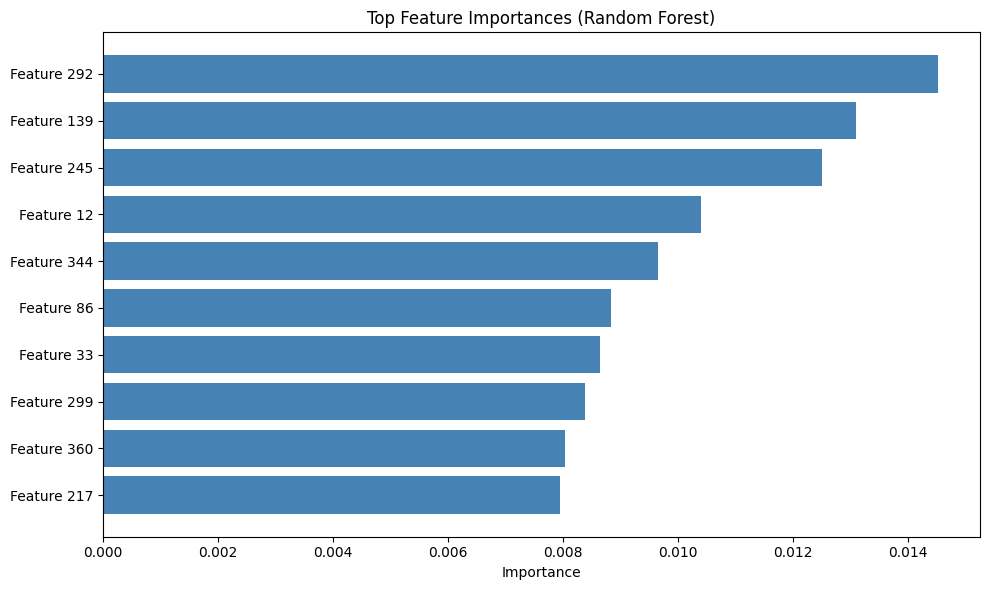

In [10]:
top_n = min(10, len(importances))
top_idx_sorted = np.argsort(importances)[-top_n:][::-1]

plt.figure(figsize=(10, 6))
plt.barh(range(top_n), importances[top_idx_sorted], color="steelblue")
plt.yticks(range(top_n), [f"Feature {i}" for i in top_idx_sorted])
plt.xlabel("Importance")
plt.title("Top Feature Importances (Random Forest)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Generate Reports

In [11]:
output_dir = Path.cwd().parent / "output" / "notebook_results"
output_dir.mkdir(exist_ok=True)

# Active metrics for report
active_mask = final_predictions != "clean"
active_pred = final_predictions[active_mask]
active_true = gt_labels[active_mask]
if len(active_pred) > 0:
    f1_macro_active = f1_score(active_true, active_pred, average="macro", zero_division=0.0)
    f1_weighted_active = f1_score(active_true, active_pred, average="weighted", zero_division=0.0)
    accuracy_active = accuracy_score(active_true, active_pred)
else:
    f1_macro_active = f1_weighted_active = accuracy_active = 0.0

report = "\n".join([
    "=" * 60, "EVALUATION REPORT", "=" * 60, "",
    f"Columns: {len(column_index)}",
    f"Classes: {len(set(gt_labels))}", "",
    "--- Full Metrics (all columns) ---",
    f"  Accuracy:    {accuracy:.4f}",
    f"  F1-macro:    {f1_macro:.4f}",
    f"  F1-weighted: {f1_weighted:.4f}", "",
    f"--- Detection Precision ({len(active_pred)} non-clean columns) ---",
    f"  Accuracy:    {accuracy_active:.4f}",
    f"  F1-macro:    {f1_macro_active:.4f}",
    f"  F1-weighted: {f1_weighted_active:.4f}", "",
    "--- Rule Engine Coverage ---",
    f"  Matched:     {n_matched} / {len(column_index)}",
    f"  Clean:       {n_clean}", "",
    "--- Random Forest (CV) ---",
    f"  F1-macro:    {scores.mean():.4f} +/- {scores.std():.4f}",
])

with open(output_dir / "evaluation_report.txt", "w") as f:
    f.write(report)

rec_text = recommender.print_recommendations(recommendations)

with open(output_dir / "recommendations.txt", "w") as f:
    f.write(rec_text)

print(f"Reports saved to {output_dir}")

Reports saved to /Users/jesusmarentes/Documents/DocumentsJesus/db_bad_clust/output/notebook_results
